<a href="https://colab.research.google.com/github/santhiya2313-spec/MachineLearning-Lab/blob/main/ML_Day10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Reshape, LeakyReLU
from tensorflow.keras.optimizers import Adam

In [2]:
df = pd.read_csv("mnist_sample_1000.csv")

X = df.iloc[:, 1:].values

X = X.astype("float32")
X = (X - 127.5) / 127.5
X = X.reshape(-1, 28, 28, 1)

print("Dataset Shape:", X.shape)

Dataset Shape: (1000, 28, 28, 1)


In [3]:
def build_generator():
    model = Sequential()
    model.add(Dense(128, input_dim=100))
    model.add(LeakyReLU(negative_slope=0.2))
    model.add(Dense(784, activation="tanh"))
    model.add(Reshape((28, 28, 1)))
    return model

In [4]:
def build_discriminator():
    model = Sequential()
    model.add(Flatten(input_shape=(28, 28, 1)))
    model.add(Dense(128))
    model.add(LeakyReLU(negative_slope=0.2))
    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        loss="binary_crossentropy",
        optimizer=Adam(0.0002, 0.5),
        metrics=["accuracy"]
    )

    return model

In [5]:
generator = build_generator()
discriminator = build_discriminator()

print("Generator Summary:")
generator.summary()

print("\nDiscriminator Summary:")
discriminator.summary()

Generator Summary:


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,064 (445.56 KB)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,609 (393.00 KB)

 Trainable params: 100,609 (393.00 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
discriminator.trainable = False

gan = Sequential()
gan.add(generator)
gan.add(discriminator)

gan.compile(
    loss="binary_crossentropy",
    optimizer=Adam(0.0002, 0.5)
)

In [7]:
epochs = 100
batch_size = 32

for epoch in range(epochs):

    # Real images
    idx = np.random.randint(0, X.shape[0], batch_size // 2)
    real_images = X[idx]

    # Fake images
    noise = np.random.normal(0, 1, (batch_size // 2, 100))
    fake_images = generator.predict(noise, verbose=0)

    # Train discriminator
    discriminator.trainable = True

    discriminator.train_on_batch(
        real_images,
        np.ones((batch_size // 2, 1))
    )

    discriminator.train_on_batch(
        fake_images,
        np.zeros((batch_size // 2, 1))
    )

    # Train generator
    discriminator.trainable = False

    noise = np.random.normal(0, 1, (batch_size, 100))

    gan.train_on_batch(
        noise,
        np.ones((batch_size, 1))
    )

    if epoch % 10 == 0:
        print("Epoch:", epoch)

Epoch: 0
Epoch: 10
Epoch: 20
Epoch: 30
Epoch: 40
Epoch: 50
Epoch: 60
Epoch: 70
Epoch: 80
Epoch: 90


In [8]:
noise = np.random.normal(0, 1, (10, 100))

generated_images = generator.predict(
    noise,
    verbose=0
)

print("Generated Images Shape:", generated_images.shape)

Generated Images Shape: (10, 28, 28, 1)


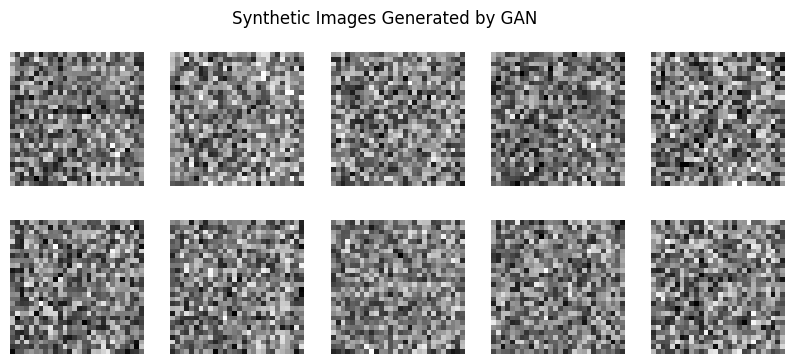

In [9]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(generated_images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("Synthetic Images Generated by GAN")
plt.show()